#Problem Definition

Physiological indicators during pregnancy—such as blood pressure, blood glucose, and heart rate—have a direct impact on the health of both the mother and fetus. In particular, high-risk pregnancies can lead to early mortality, preterm birth, or complications, making early prediction and medical intervention critically important.

To address this, we develop a machine learning model that classifies each pregnant woman's risk level (Low, Mid, High) based on her physiological data during pregnancy.


---



Dataset ： https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data/data

* Age: Age in years when a woman is pregnant.

* SystolicBP: Upper value of Blood Pressure in mmHg, another significant attribute during pregnancy.

* DiastolicBP: Lower value of Blood Pressure in mmHg, another significant attribute during pregnancy.

* BS: Blood glucose levels is in terms of a molar concentration, mmol/L.

* HeartRate: A normal resting heart rate in beats per minute.

* Risk Level: Predicted Risk Intensity Level during pregnancy considering the previous attribute.

In [ ]:
!pip install -r requirements.txt

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from scipy.stats import boxcox
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


#Reading  Data

In [ ]:
import kagglehub

path = kagglehub.dataset_download("csafrit2/maternal-health-risk-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/maternal-health-risk-data


In [ ]:
df = pd.read_csv("/kaggle/input/maternal-health-risk-data/Maternal Health Risk Data Set.csv")

print(df.head())

   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [ ]:
df.describe(include='all')

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014
unique,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,low risk
freq,NaN,NaN,NaN,NaN,NaN,NaN,406
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,NaN
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,NaN
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,NaN
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,NaN
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,NaN
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,NaN


#Data Cleaning

(1) Remove duplicates

In [ ]:
dup = df.duplicated().sum()
print(f"Found {dup} duplicate rows")
if dup:
    df.drop_duplicates(inplace=True)

Found 562 duplicate rows


(2) Handle missing values

In [ ]:
nul_num = df.isnull().sum().sort_values(ascending=False)
nul_num #결측치없음

,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0
RiskLevel,0


(3) Remove outliers

In [ ]:
physio_bounds = {
    'Age':         (15,   49),
    'SystolicBP':  (70,  200),
    'DiastolicBP': (50,  120),
    'BS':          (2.8, 15.0),
    'BodyTemp':    (95.0,104.0),
    'HeartRate':   (40,  150)
}

mask_bad = pd.Series(False, index=df.index)
for col,(lo,hi) in physio_bounds.items():
    mask_bad |= (df[col] < lo) | (df[col] > hi)

print("Rows to drop (implausible):", mask_bad.sum())
df = df.loc[~mask_bad].copy()
print("After domain filter rows:", df.shape[0])
df.describe()

Rows to drop (implausible): 116
After domain filter rows: 336


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,26.074405,110.827381,76.122024,7.829375,98.690476,74.238095
std,8.363592,16.899703,12.882013,1.825621,1.411392,7.443910
min,15.000000,70.000000,50.000000,6.000000,98.000000,60.000000
25%,20.000000,99.750000,65.000000,6.900000,98.000000,70.000000
50%,23.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,32.000000,120.000000,89.250000,7.800000,98.000000,80.000000
max,49.000000,140.000000,100.000000,15.000000,103.000000,90.000000


#EDA

In [ ]:
sns.set_style('whitegrid')
num_cols = ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']
cat_col = 'RiskLevel'

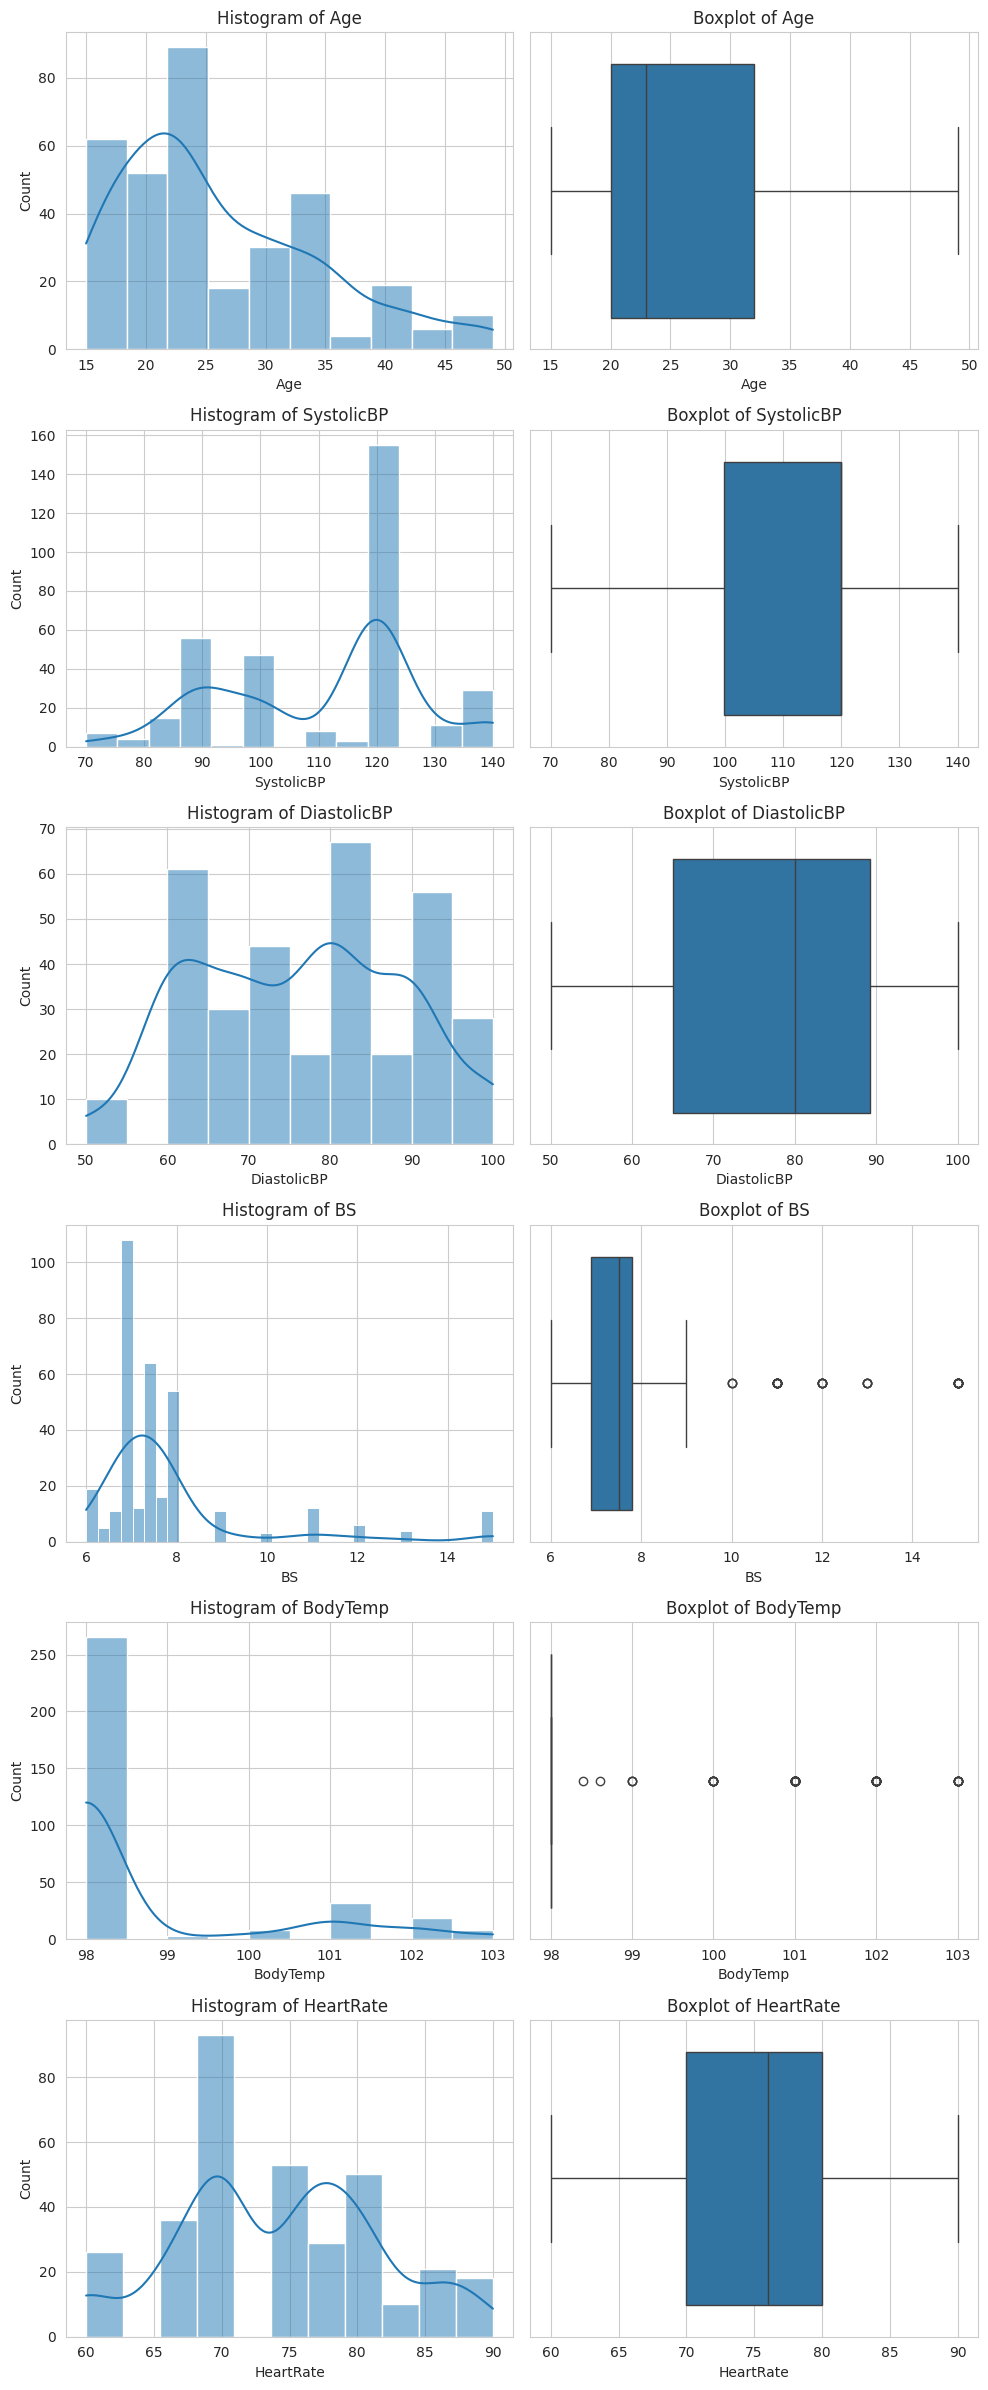

In [ ]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 4*len(num_cols)))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=axes[i,0], kde=True)
    axes[i,0].set_title(f"Histogram of {col}")
    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

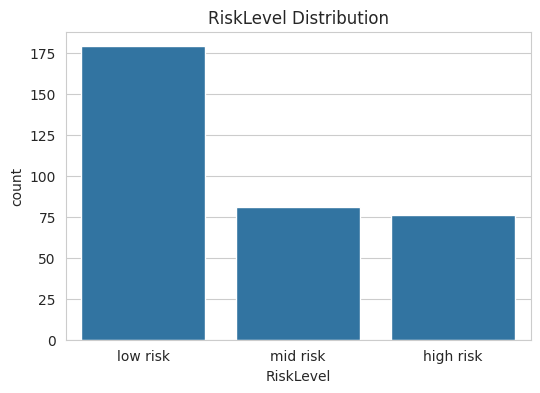

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=cat_col, data=df, order=df[cat_col].value_counts().index)
plt.title('RiskLevel Distribution')
plt.show()

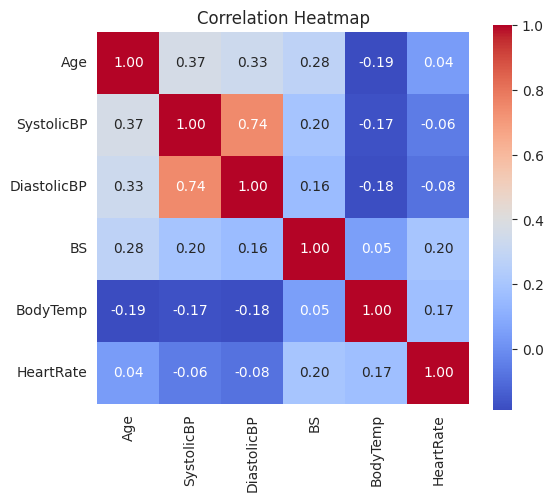

In [ ]:
plt.figure(figsize=(6, 5))
correlation = df[num_cols].corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

<ipython-input-13-cbce50a37769>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='RiskLevel', y=col, data=df, inner='quartile', palette='pastel')
<ipython-input-13-cbce50a37769>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='RiskLevel', y=col, data=df, inner='quartile', palette='pastel')
<ipython-input-13-cbce50a37769>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='RiskLevel', y=col, data=df, inner='quartile', palette='pastel')
<ipython-input-13-cbce50a37769>:4: FutureWarning: 

Passing `palette` without assigning `hue` 

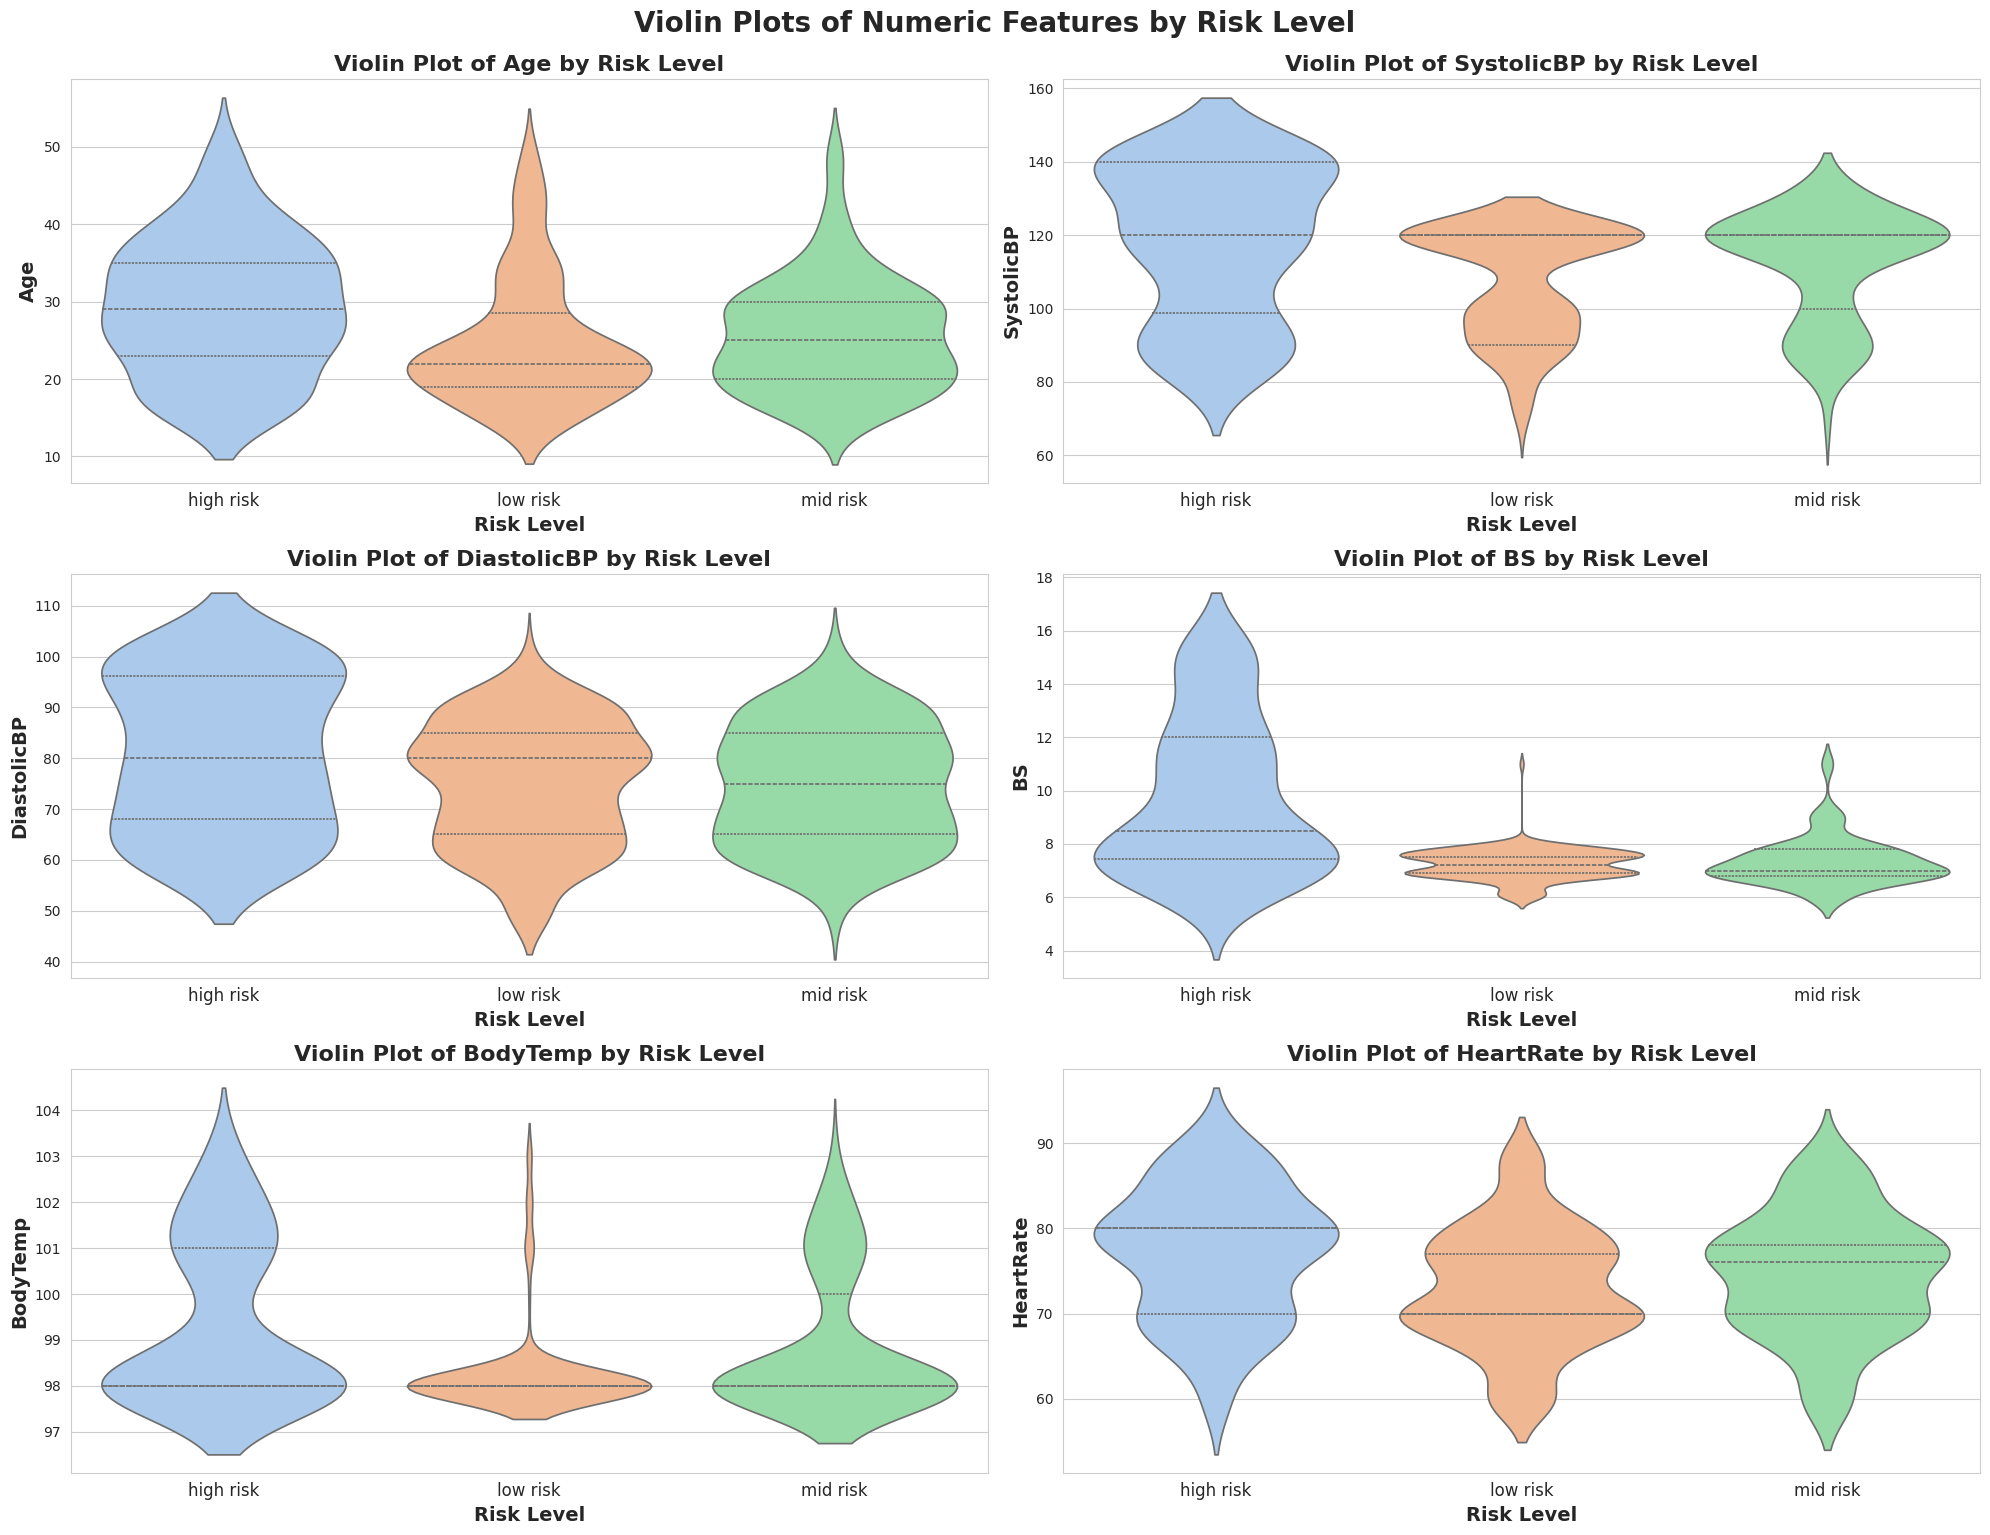

In [ ]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(df.select_dtypes(include=['int64', 'float64']).columns):
    plt.subplot(3, 2, i + 1)
    sns.violinplot(x='RiskLevel', y=col, data=df, inner='quartile', palette='pastel')
    plt.title(f'Violin Plot of {col} by Risk Level', fontsize=16, fontweight='bold')
    plt.xlabel('Risk Level', fontsize=14, fontweight='bold')
    plt.ylabel(col, fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12)

plt.tight_layout()
plt.suptitle('Violin Plots of Numeric Features by Risk Level', fontsize=20, fontweight='bold', y=1.02)
plt.show()

#Data Preprocessing

(1) Skewness Correction

In [ ]:
skew_limit = 0.75

mask = df.dtypes != object
num_cols = df.columns[mask]

skew_vals = df[num_cols].skew()

skew_cols = (skew_vals
             .sort_values(ascending=False)
             .to_frame(name='Skew')
             .query('abs(Skew) > @skew_limit'))

skew_cols


,Skew
BS,2.589450
BodyTemp,1.766979
Age,0.864107


In [ ]:
df['BS_boxcox'], bs_lambda = boxcox(df['BS'])
df['BS'] = df['BS_boxcox']
df.drop(columns=['BS_boxcox'], inplace=True)

pt_age = PowerTransformer(method='yeo-johnson')
df['Age'] = pt_age.fit_transform(df[['Age']])

print(df[['BS', 'Age', 'BodyTemp']].skew())


BS          0.061940
Age         0.047039
BodyTemp    1.766979
dtype: float64


(2) Label Encoding and Feature Scaling

In [ ]:
X = df[num_cols]
y = df[cat_col]

# 라벨 인코딩 및 스케일링
le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#ML Models

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_configs = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']
        }
    },
    'RF': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 5, 10]
        }
    },
    'XGB': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.05, 0.1]
        }
    }
}

In [ ]:
def smote_cv_score(model, X, y, skf, scoring):
    scores = []
    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X[train_idx], X[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

        model.fit(X_res, y_res)
        if scoring == 'accuracy':
            pred = model.predict(X_valid)
            scores.append(accuracy_score(y_valid, pred))
        elif scoring == 'f1_macro':
            pred = model.predict(X_valid)
            scores.append(f1_score(y_valid, pred, average='macro'))
        elif scoring == 'roc_auc_ovr':
            prob = model.predict_proba(X_valid)
            scores.append(roc_auc_score(y_valid, prob, multi_class='ovr'))
    return np.mean(scores), np.std(scores)


results = []
best_models = {}

for name, cfg in model_configs.items():
    print(f"\n=== {name} ===")
    model_cls = cfg['model'].__class__
    param_grid = cfg['params']

    base_model = cfg['model']

    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', base_model)
    ])

    param_grid_prefixed = {f'clf__{k}': v for k, v in param_grid.items()}

    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_prefixed,
        cv=skf,
        scoring='accuracy',
        n_jobs=-1
    )
    gs.fit(X_scaled, y_enc)
    best_model = gs.best_estimator_
    best_models[name] = best_model

    acc_mean, acc_std = smote_cv_score(best_model, X_scaled, y_enc, skf, 'accuracy')
    auc_mean, auc_std = smote_cv_score(best_model, X_scaled, y_enc, skf, 'roc_auc_ovr')
    f1_mean, f1_std   = smote_cv_score(best_model, X_scaled, y_enc, skf, 'f1_macro')

    print(f"Best Params: {gs.best_params_}")
    print(f"CV Accuracy: {acc_mean:.3f} ± {acc_std:.3f}")
    print(f"CV ROC-AUC: {auc_mean:.3f} ± {auc_std:.3f}")
    print(f"CV F1-macro: {f1_mean:.3f} ± {f1_std:.3f}")

    results.append({
        'Model': name,
        'Accuracy': acc_mean,
        'ROC-AUC': auc_mean,
        'F1-Macro': f1_mean
    })


results_df = pd.DataFrame(results)
print(results_df)



=== KNN ===
Best Params: {'clf__n_neighbors': 7, 'clf__weights': 'uniform'}
CV Accuracy: 0.577 ± 0.063
CV ROC-AUC: 0.724 ± 0.029
CV F1-macro: 0.549 ± 0.052

=== RF ===
Best Params: {'clf__max_depth': 5, 'clf__n_estimators': 300}
CV Accuracy: 0.699 ± 0.047
CV ROC-AUC: 0.781 ± 0.039
CV F1-macro: 0.646 ± 0.056

=== XGB ===


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:06:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:06:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:06:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:06:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:06:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Best Params: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 100}
CV Accuracy: 0.673 ± 0.047
CV ROC-AUC: 0.773 ± 0.040
CV F1-macro: 0.615 ± 0.046
  Model  Accuracy   ROC-AUC  F1-Macro
0   KNN  0.577392  0.724448  0.549454
1    RF  0.699298  0.781112  0.645537
2   XGB  0.672608  0.772924  0.615286


#SHAP

In [ ]:
import shap
shap.initjs()

X_plot = pd.DataFrame(X_scaled, columns=num_cols)

rf_model = best_models['RF'].named_steps['clf']

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_plot)

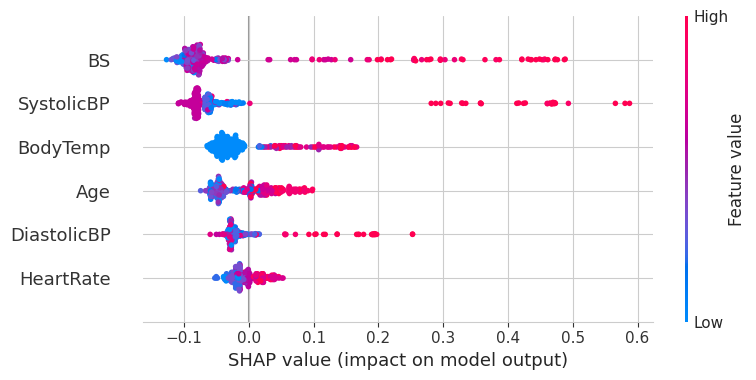

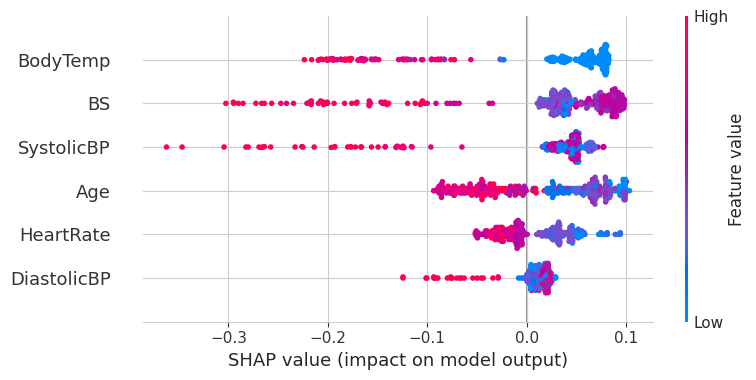

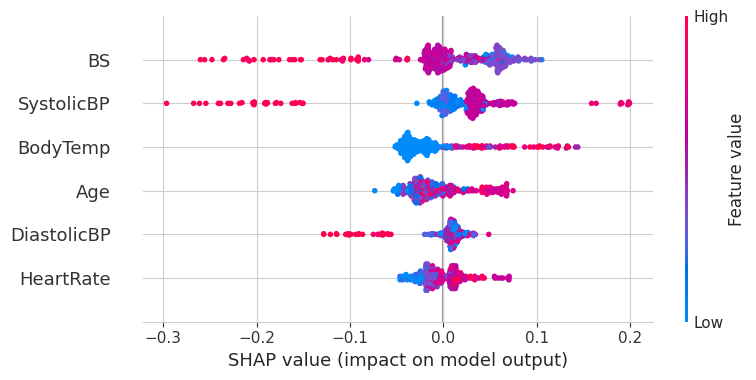

In [ ]:
shap.summary_plot(shap_values[..., 0], X_scaled, feature_names=num_cols)

shap.summary_plot(shap_values[..., 1], X_scaled, feature_names=num_cols)

shap.summary_plot(shap_values[..., 2], X_scaled, feature_names=num_cols)


Predicted Class : high risk


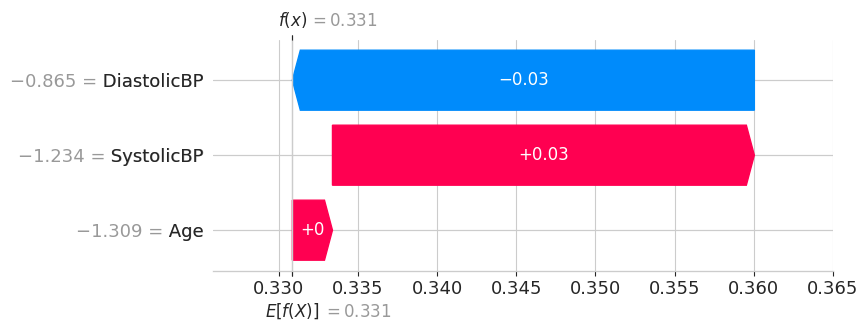

In [ ]:
patient_idx = 300
rf_model = best_models['RF'].named_steps['clf']
pred_class = rf_model.predict([X_scaled[patient_idx]])[0]
pred_class_name = le.inverse_transform([pred_class])[0]
print("Predicted Class :", pred_class_name)

explanation = shap.Explanation(
    values=shap_values.values[patient_idx, pred_class],
    base_values=shap_values.base_values[patient_idx, pred_class],
    data=X_plot.iloc[patient_idx],
    feature_names=num_cols
)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
shap.plots.waterfall(explanation, max_display=6)
